In [2]:
from IPython.display import Image, display
import glob, os, subprocess, shlex
import numpy as np
import nibabel as nib
import matplotlib.pyplot as plt
from scipy import ndimage

In [3]:
!which bet
!bet --help | head

/home/bami/fsl/share/fsl/bin/bet

Usage:    bet <input> <output> [options]

Main bet2 options:
  -o          generate brain surface outline overlaid onto original image
  -m          generate binary brain mask
  -s          generate approximate skull image
  -n          don't generate segmented brain image output
  -f <f>      fractional intensity threshold (0->1); default=0.5; smaller values give larger brain outline estimates
  -g <g>      vertical gradient in fractional intensity threshold (-1->1); default=0; positive values give larger brain outline at bottom, smaller at top


In [4]:
## Defines

def load_img(path):
    if not os.path.exists(path):
        raise FileNotFoundError(f"Missing file: {path}")
    img = nib.load(path)
    hdr = img.header
    print(f"\n[FILE] {path}")
    print(f"  shape (X, Y, Z / Vol)    : {img.shape}")
    print(f"  Voxel size (Partial Res) : {hdr.get_zooms()}")
    if len(img.shape) == 4:
        print(f"  TR    : {hdr.get_zooms()[3]} sec")
    return img

def _savefig(out_png, dpi=300):
    if out_png:
        os.makedirs(os.path.dirname(out_png), exist_ok=True)
        plt.savefig(out_png, dpi=dpi, bbox_inches="tight")
    plt.show()
    plt.close()

def show_orth(vol3d, title, vmax=None, out_png=None):
    y, x, z = vol3d.shape
    cx, cy, cz = x//2, y//2, z//2

    sag = np.take(vol3d, indices=cx, axis=0)
    cor = np.take(vol3d, indices=cy, axis=1)
    axi = np.take(vol3d, indices=cz, axis=2)

    fig, axs = plt.subplots(1, 3, figsize=(12, 4))
    axs[0].imshow(np.rot90(sag), cmap="gray", vmax=vmax); axs[0].set_title(f"{title} | Sag")
    axs[1].imshow(np.rot90(cor), cmap="gray", vmax=vmax); axs[1].set_title(f"{title} | Cor")
    axs[2].imshow(np.rot90(axi), cmap="gray", vmax=vmax); axs[2].set_title(f"{title} | Axial")
    for a in axs: a.axis("off")
    plt.tight_layout()
    _savefig(out_png)

def show_bold_quick(img4d, title, out_png_mean=None, out_png_gm=None):
    data = img4d.get_fdata(dtype=np.float32)
    mean3d = data.mean(axis=3)

    vmax = np.percentile(mean3d[np.isfinite(mean3d)], 99)
    show_orth(mean3d, f"{title} (mean BOLD)", vmax=vmax, out_png=out_png_mean)

    gm = data.reshape(-1, data.shape[3]).mean(axis=0)
    plt.figure(figsize=(10, 2.5))
    plt.plot(gm, linewidth=1.0)
    plt.title(f"{title} | Global mean BOLD (raw)")
    plt.xlabel("Time (volumes)")
    plt.ylabel("Mean signal")
    plt.tight_layout()
    _savefig(out_png_gm)

# BOLD-mask 기반 QC calc logics
def erode_mask(mask, it=2):
    return ndimage.binary_erosion(mask, iterations=it).astype(bool) if it > 0 else mask.astype(bool)

def tsnr_map(data4d, mask):
    m = data4d.mean(axis=3)
    s = data4d.std(axis=3, ddof=0)
    out = np.zeros_like(m, dtype=np.float32)
    out[mask] = m[mask] / (s[mask] + 1e-6)
    return out

def dvars_simple(data4d, mask):
    X = data4d[mask]
    dX = np.diff(X, axis=1)
    return np.sqrt(np.mean(dX**2, axis=0)).astype(np.float32)

def mad(x):
    med = np.median(x)
    return np.median(np.abs(x - med)) + 1e-12

def detect_spikes_mad(x, k=3.5):
    thr = np.median(x) + k * mad(x)
    idx = np.where(x > thr)[0]
    return float(thr), idx

def plot_ts(g, gm, title, out_png=None):
    plt.figure(figsize=(11,3))
    plt.plot(g,  label="Global mean (BOLD mask)", linewidth=1)
    plt.plot(gm, label="GM-like mean (eroded mask)", linewidth=1)
    plt.title(f"{title} | Mean time series (masked)")
    plt.xlabel("Time (volumes)")
    plt.ylabel("Mean signal")
    plt.legend()
    plt.tight_layout()
    _savefig(out_png)

def plot_dvars(dv, title, out_png=None):
    thr, spikes = detect_spikes_mad(dv, k=3.5)
    plt.figure(figsize=(11,2.7))
    plt.plot(dv, linewidth=1)
    plt.axhline(thr, linestyle="--", linewidth=1)
    plt.title(f"{title} | DVARS (masked) | spikes={len(spikes)}")
    plt.xlabel("Time (diff volumes)")
    plt.ylabel("DVARS")
    plt.tight_layout()
    _savefig(out_png)
    return thr, spikes

def save_mean_bold(bold_path, out_path):
    img = nib.load(bold_path)
    data = img.get_fdata(dtype=np.float32)
    mean3d = data.mean(axis=3)
    nib.save(nib.Nifti1Image(mean3d.astype(np.float32), img.affine, img.header), out_path)
    print("Saved meanBOLD:", out_path, "shape:", mean3d.shape)
    return out_path

In [4]:
## T1-BET Masking

[CMD] bet /media/bami/JHA/rsCVR/data/OpenNeuro/ds003768/sub-01/anat/sub-01_T1w.nii.gz /media/bami/JHA/rsCVR/data/OpenNeuro/ds003768/sub-01/results/sub-01_T1w_brain_bet_f475 -m -R -f 0.475

[OUTPUT SAVED]
 results dir : /media/bami/JHA/rsCVR/data/OpenNeuro/ds003768/sub-01/results
 brain       : /media/bami/JHA/rsCVR/data/OpenNeuro/ds003768/sub-01/results/sub-01_T1w_brain_bet_f475.nii.gz
 mask        : /media/bami/JHA/rsCVR/data/OpenNeuro/ds003768/sub-01/results/sub-01_T1w_brain_bet_f475_mask.nii.gz

[FILE] /media/bami/JHA/rsCVR/data/OpenNeuro/ds003768/sub-01/anat/sub-01_T1w.nii.gz
  shape (X, Y, Z / Vol)    : (192, 256, 256)
  Voxel size (Partial Res) : (np.float32(0.9999971), np.float32(1.0), np.float32(1.0))

[FILE] /media/bami/JHA/rsCVR/data/OpenNeuro/ds003768/sub-01/results/sub-01_T1w_brain_bet_f475.nii.gz
  shape (X, Y, Z / Vol)    : (192, 256, 256)
  Voxel size (Partial Res) : (np.float32(0.9999971), np.float32(1.0), np.float32(1.0))

[FILE] /media/bami/JHA/rsCVR/data/OpenNeuro/ds

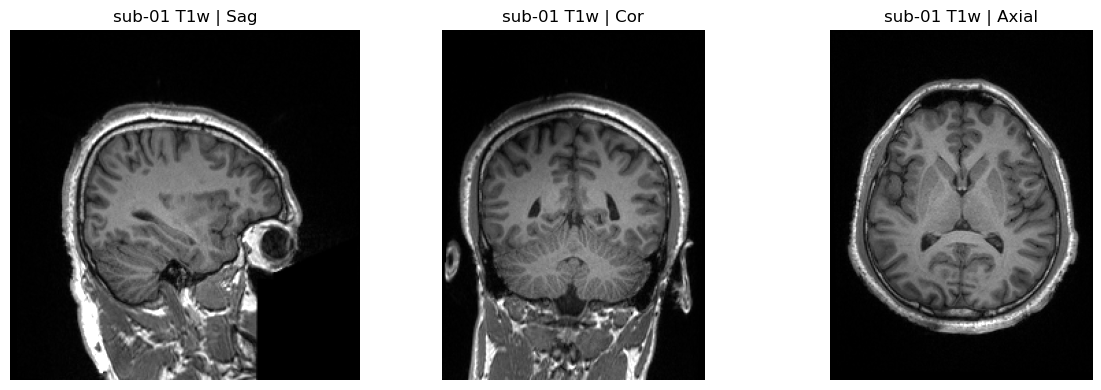

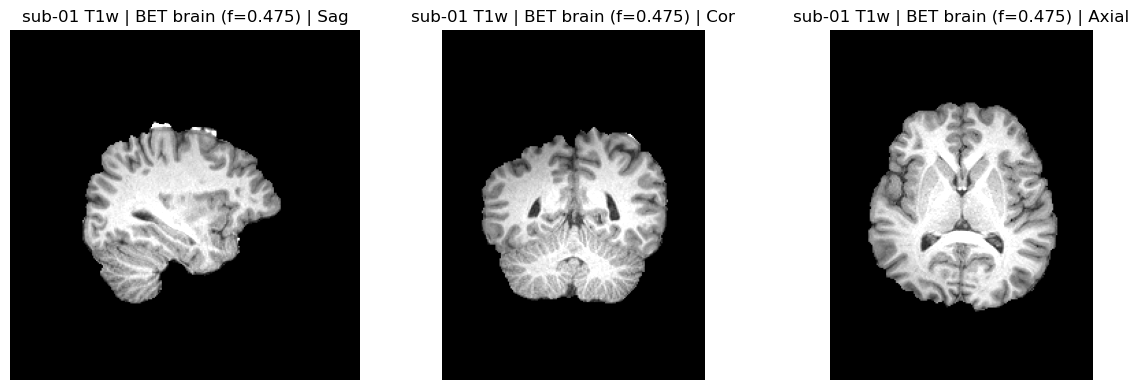

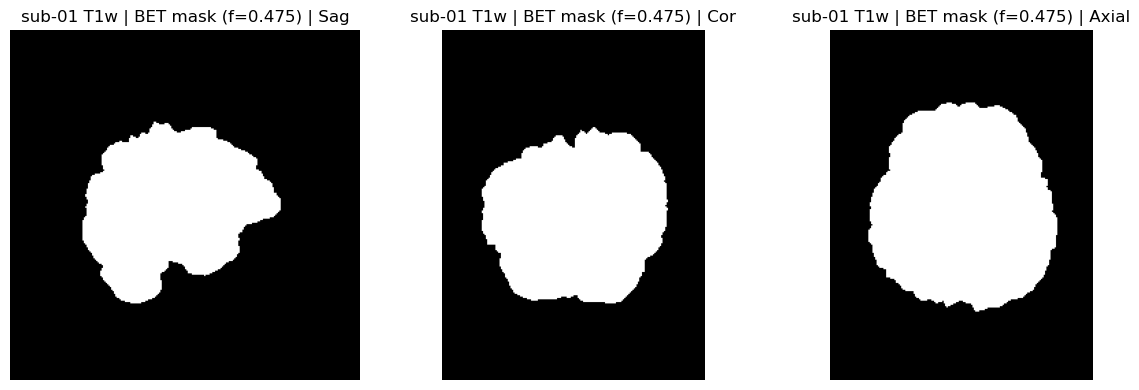

In [5]:
base = r"/media/bami/JHA/rsCVR/data/OpenNeuro/ds003768"
sub  = "sub-01"

t1 = os.path.join(base, sub, "anat", f"{sub}_T1w.nii.gz")
res_dir = os.path.join(base, sub, "results")
fig_dir = os.path.join(res_dir, "figs")
os.makedirs(fig_dir, exist_ok=True)

fval = 0.475  # f-value
out_prefix = os.path.join(res_dir, f"{sub}_T1w_brain_bet_f{int(fval*1000):03d}")

cmd = f"bet {shlex.quote(t1)} {shlex.quote(out_prefix)} -m -R -f {fval}"
print("[CMD]", cmd)
subprocess.run(cmd, shell=True, check=True)

brain_path = out_prefix + ".nii.gz"
mask_path  = out_prefix + "_mask.nii.gz"
print("\n[OUTPUT SAVED]")
print(" results dir :", res_dir)
print(" brain       :", brain_path)
print(" mask        :", mask_path)

t1_img    = load_img(t1)
brain_img = load_img(brain_path)
mask_img  = load_img(mask_path)

t1_data    = t1_img.get_fdata(dtype=np.float32)
brain_data = brain_img.get_fdata(dtype=np.float32)
mask_data  = mask_img.get_fdata(dtype=np.float32)

vmax_t1 = np.percentile(t1_data[np.isfinite(t1_data)], 99.5)
show_orth(t1_data,    f"{sub} T1w", vmax=vmax_t1,
          out_png=os.path.join(fig_dir, f"{sub}_T1w.png"))
show_orth(brain_data, f"{sub} T1w | BET brain (f={fval})",
          vmax=np.percentile(brain_data[np.isfinite(brain_data)], 99.5),
          out_png=os.path.join(fig_dir, f"{sub}_T1w_BETbrain_f{int(fval*1000):03d}.png"))
show_orth(mask_data,  f"{sub} T1w | BET mask (f={fval})",
          out_png=os.path.join(fig_dir, f"{sub}_T1w_BETmask_f{int(fval*1000):03d}.png"))

In [6]:
## T1 BET MASK --> BOLD img + QC

In [37]:
sub = "sub-01"
fv = 475

# inputs
t1      = os.path.join(base, sub, "anat", f"{sub}_T1w.nii.gz")
t1_br   = os.path.join(res_dir, f"{sub}_T1w_brain_bet_f{fv}.nii.gz")
t1_mask = os.path.join(res_dir, f"{sub}_T1w_brain_bet_f{fv}_mask.nii.gz")
rs1     = os.path.join(base, sub, "func", f"{sub}_task-rest_run-1_bold.nii.gz")
rs2     = os.path.join(base, sub, "func", f"{sub}_task-rest_run-2_bold.nii.gz")

# outputs
mean1_path  = os.path.join(res_dir, f"{sub}_run-1_meanBOLD.nii.gz")
mean2_path  = os.path.join(res_dir, f"{sub}_run-2_meanBOLD.nii.gz")
t12bold_mat = os.path.join(res_dir, f"{sub}_T1toBOLD_run1.mat")
t1_in_bold  = os.path.join(res_dir, f"{sub}_T1w_in_run1BOLD.nii.gz")
mask_bold   = os.path.join(res_dir, f"{sub}_T1w_BETmask_in_run1BOLD.nii.gz")

print("[RESULTS DIR]", res_dir)
print("[FIG DIR]    ", fig_dir)

[RESULTS DIR] /media/bami/JHA/rsCVR/data/OpenNeuro/ds003768/sub-01/results
[FIG DIR]     /media/bami/JHA/rsCVR/data/OpenNeuro/ds003768/sub-01/results/figs


Saved meanBOLD: /media/bami/JHA/rsCVR/data/OpenNeuro/ds003768/sub-01/results/sub-01_run-1_meanBOLD.nii.gz shape: (80, 80, 35)
Saved meanBOLD: /media/bami/JHA/rsCVR/data/OpenNeuro/ds003768/sub-01/results/sub-01_run-2_meanBOLD.nii.gz shape: (80, 80, 35)

[FILE] /media/bami/JHA/rsCVR/data/OpenNeuro/ds003768/sub-01/results/sub-01_run-1_meanBOLD.nii.gz
  shape (X, Y, Z / Vol)    : (80, 80, 35)
  Voxel size (Partial Res) : (np.float32(3.0), np.float32(3.0), np.float32(4.0))

[FILE] /media/bami/JHA/rsCVR/data/OpenNeuro/ds003768/sub-01/results/sub-01_run-2_meanBOLD.nii.gz
  shape (X, Y, Z / Vol)    : (80, 80, 35)
  Voxel size (Partial Res) : (np.float32(3.0), np.float32(3.0), np.float32(4.0))


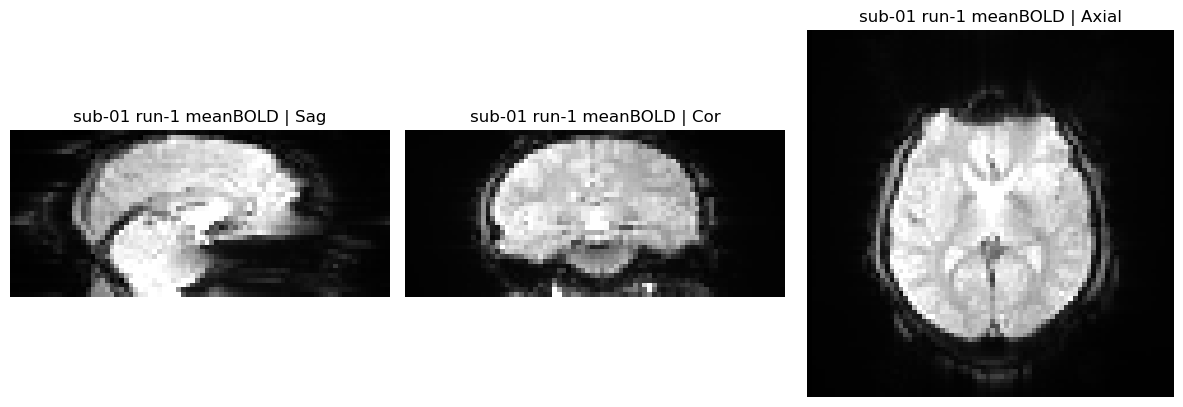

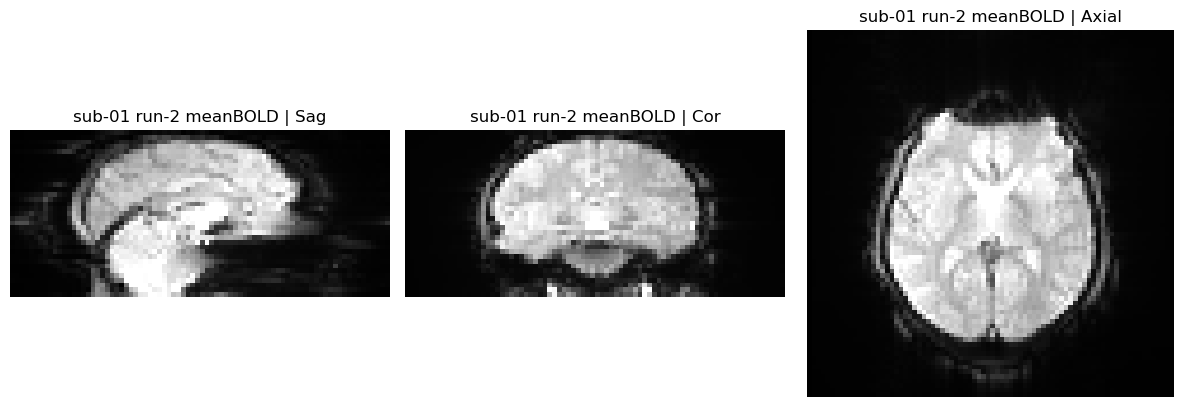


[CMD] flirt -in /media/bami/JHA/rsCVR/data/OpenNeuro/ds003768/sub-01/results/sub-01_T1w_brain_bet_f475.nii.gz -ref /media/bami/JHA/rsCVR/data/OpenNeuro/ds003768/sub-01/results/sub-01_run-1_meanBOLD.nii.gz -omat /media/bami/JHA/rsCVR/data/OpenNeuro/ds003768/sub-01/results/sub-01_T1toBOLD_run1.mat -out /media/bami/JHA/rsCVR/data/OpenNeuro/ds003768/sub-01/results/sub-01_T1w_in_run1BOLD.nii.gz
[CMD] flirt -in /media/bami/JHA/rsCVR/data/OpenNeuro/ds003768/sub-01/results/sub-01_T1w_brain_bet_f475_mask.nii.gz -ref /media/bami/JHA/rsCVR/data/OpenNeuro/ds003768/sub-01/results/sub-01_run-1_meanBOLD.nii.gz -applyxfm -init /media/bami/JHA/rsCVR/data/OpenNeuro/ds003768/sub-01/results/sub-01_T1toBOLD_run1.mat -interp nearestneighbour -out /media/bami/JHA/rsCVR/data/OpenNeuro/ds003768/sub-01/results/sub-01_T1w_BETmask_in_run1BOLD.nii.gz

[OUTPUT SAVED]
 mat   : /media/bami/JHA/rsCVR/data/OpenNeuro/ds003768/sub-01/results/sub-01_T1toBOLD_run1.mat
 t1->B : /media/bami/JHA/rsCVR/data/OpenNeuro/ds003768

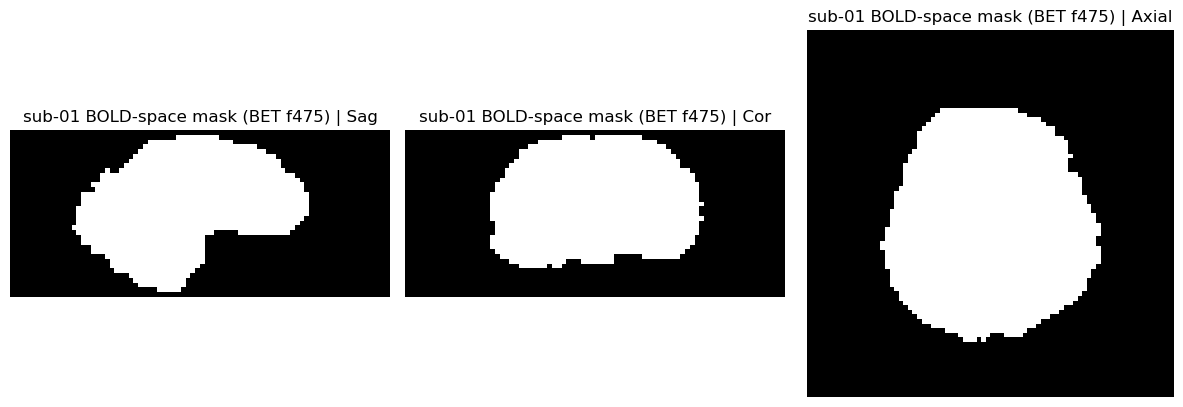

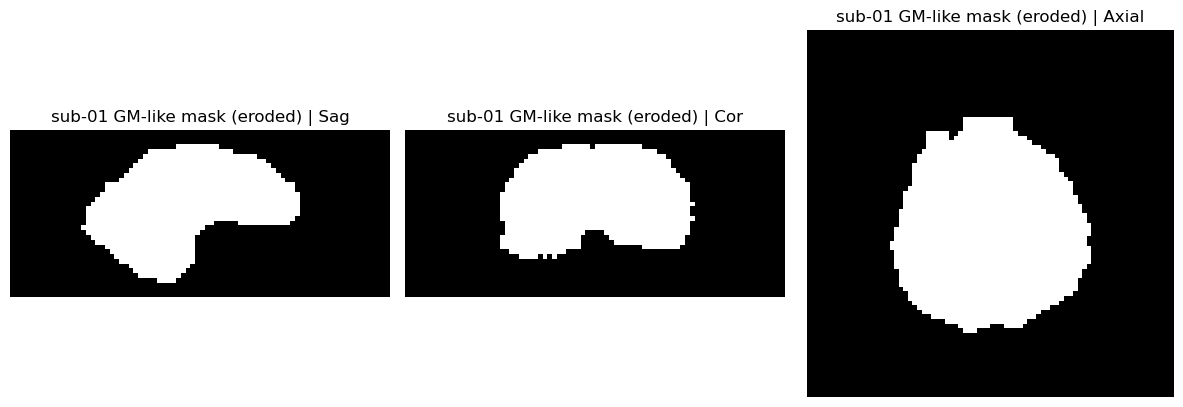


[FILE] /media/bami/JHA/rsCVR/data/OpenNeuro/ds003768/sub-01/func/sub-01_task-rest_run-1_bold.nii.gz
  shape (X, Y, Z / Vol)    : (80, 80, 35, 286)
  Voxel size (Partial Res) : (np.float32(3.0), np.float32(3.0), np.float32(4.0), np.float32(2.1))
  TR    : 2.0999999046325684 sec


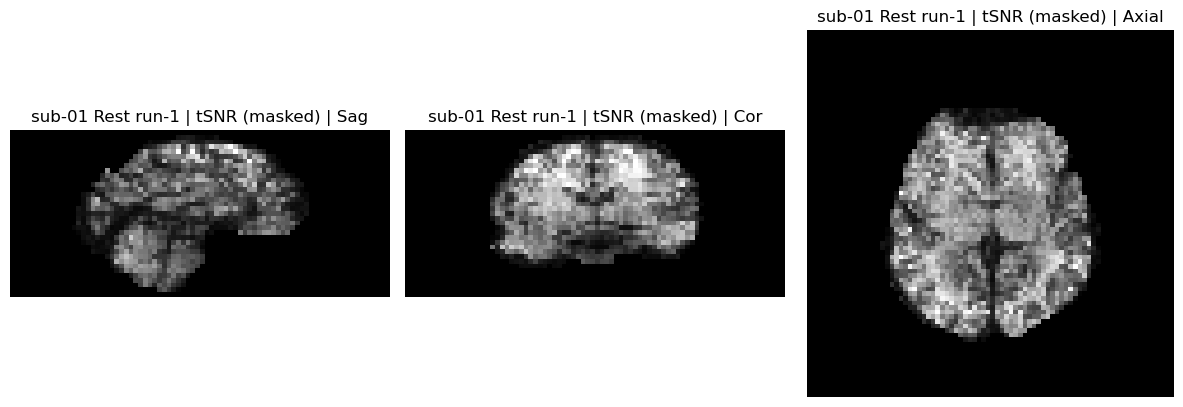

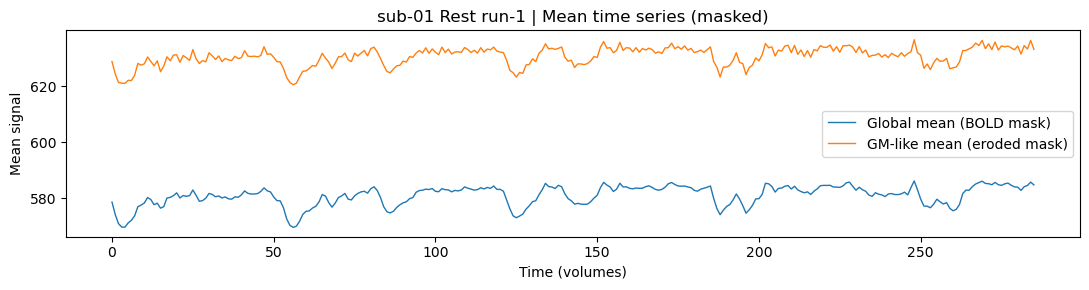

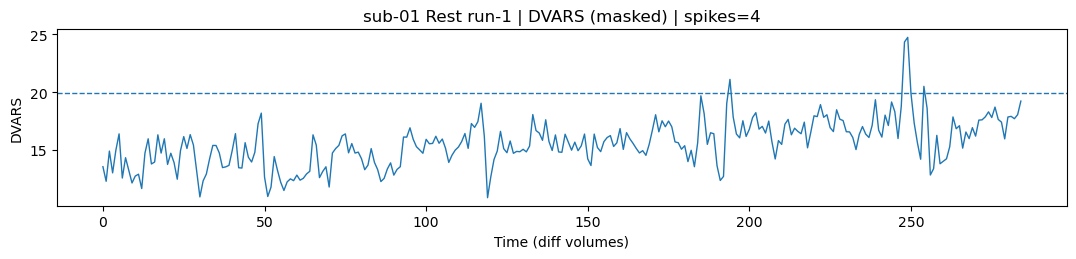


[FILE] /media/bami/JHA/rsCVR/data/OpenNeuro/ds003768/sub-01/func/sub-01_task-rest_run-2_bold.nii.gz
  shape (X, Y, Z / Vol)    : (80, 80, 35, 286)
  Voxel size (Partial Res) : (np.float32(3.0), np.float32(3.0), np.float32(4.0), np.float32(2.1))
  TR    : 2.0999999046325684 sec


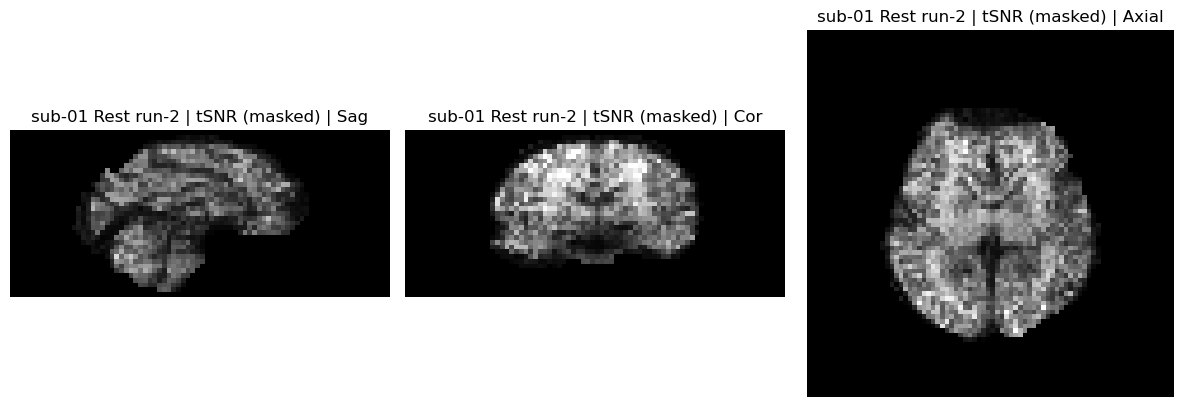

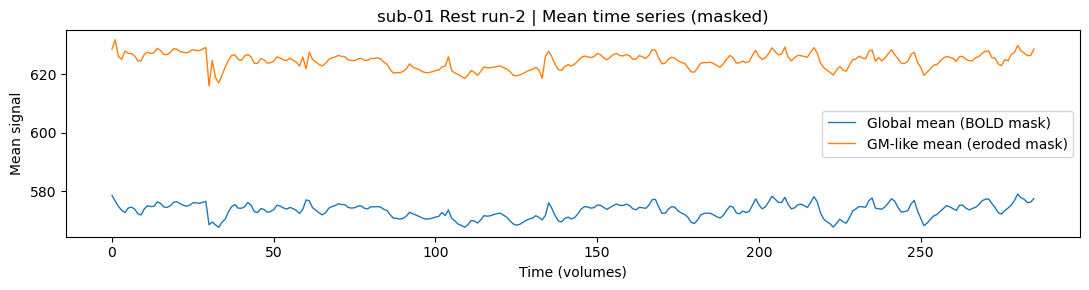

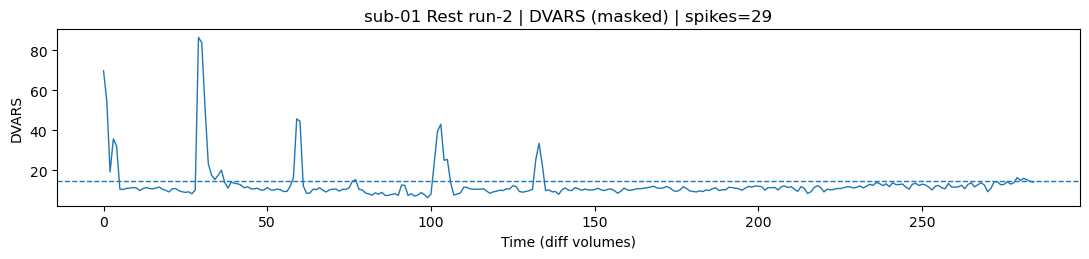


[SAVED]
 QC summary: /media/bami/JHA/rsCVR/data/OpenNeuro/ds003768/sub-01/results/sub-01_QC_summary_f475.csv
 figs dir  : /media/bami/JHA/rsCVR/data/OpenNeuro/ds003768/sub-01/results/figs
 run-1 vs run-2 | mean tSNR: 63.30 vs 53.30 | spikes: 4 vs 29


In [38]:
# Save mean BOLD
save_mean_bold(rs1, mean1_path)
save_mean_bold(rs2, mean2_path)

mean1_img = load_img(mean1_path)
mean2_img = load_img(mean2_path)

m1 = mean1_img.get_fdata(dtype=np.float32)
m2 = mean2_img.get_fdata(dtype=np.float32)

show_orth(m1, f"{sub} run-1 meanBOLD",
          vmax=np.percentile(m1[np.isfinite(m1)], 99),
          out_png=os.path.join(fig_dir, f"{sub}_run-1_meanBOLD.png"))
show_orth(m2, f"{sub} run-2 meanBOLD",
          vmax=np.percentile(m2[np.isfinite(m2)], 99),
          out_png=os.path.join(fig_dir, f"{sub}_run-2_meanBOLD.png"))

# T1 BET mask --> BOLD space (run-1 meanBOLD 기준)
# 1) T1 brain --> BOLD mean으로 정합(Linear)
cmd1 = f"flirt -in {shlex.quote(t1_br)} -ref {shlex.quote(mean1_path)} -omat {shlex.quote(t12bold_mat)} -out {shlex.quote(t1_in_bold)}"
print("\n[CMD]", cmd1); subprocess.run(cmd1, shell=True, check=True)
# 2) 같은 변환을 mask로 적용 (nearest neighbour)
cmd2 = f"flirt -in {shlex.quote(t1_mask)} -ref {shlex.quote(mean1_path)} -applyxfm -init {shlex.quote(t12bold_mat)} -interp nearestneighbour -out {shlex.quote(mask_bold)}"
print("[CMD]", cmd2); subprocess.run(cmd2, shell=True, check=True)

print("\n[OUTPUT SAVED]")
print(" mat   :", t12bold_mat)
print(" t1->B :", t1_in_bold)
print(" maskB :", mask_bold)


# Load masks
mask_img = load_img(mask_bold)
mask = (mask_img.get_fdata() > 0.5)

show_orth(mask.astype(np.float32), f"{sub} BOLD-space mask (BET f{fv})",
          out_png=os.path.join(fig_dir, f"{sub}_mask_in_run1BOLD_f{fv}.png"))

gm_like = erode_mask(mask, it=2)
show_orth(gm_like.astype(np.float32), f"{sub} GM-like mask (eroded)",
          out_png=os.path.join(fig_dir, f"{sub}_gm_like_mask.png"))

def qc_run(bold_path, title, tag):
    img = load_img(bold_path)
    data = img.get_fdata(dtype=np.float32)

    # tSNR map 저장 + figure 저장
    tsnr = tsnr_map(data, mask)
    tsnr_path = os.path.join(res_dir, f"{sub}_{tag}_tSNR_masked.nii.gz")
    nib.save(nib.Nifti1Image(tsnr.astype(np.float32), img.affine, img.header), tsnr_path)

    vmax = np.percentile(tsnr[tsnr > 0], 99) if np.any(tsnr > 0) else None
    show_orth(tsnr, f"{title} | tSNR (masked)", vmax=vmax,
              out_png=os.path.join(fig_dir, f"{sub}_{tag}_tSNR.png"))

    # mean TS figure 저장
    X = data.reshape(-1, data.shape[3])
    g  = X[mask.ravel()].mean(axis=0)
    gm = X[gm_like.ravel()].mean(axis=0) if gm_like.sum() else g.copy()
    plot_ts(g, gm, title, out_png=os.path.join(fig_dir, f"{sub}_{tag}_meanTS.png"))

    # DVARS + figure + npy 저장
    dv = dvars_simple(data, mask)
    thr, spikes = plot_dvars(dv, title, out_png=os.path.join(fig_dir, f"{sub}_{tag}_DVARS.png"))

    np.save(os.path.join(res_dir, f"{sub}_{tag}_DVARS.npy"), dv)
    np.save(os.path.join(res_dir, f"{sub}_{tag}_DVARS_spike_idx.npy"), spikes.astype(int))

    summ = {
        "run": tag,
        "n_vol": int(data.shape[3]),
        "mask_vox": int(mask.sum()),
        "gm_like_vox": int(gm_like.sum()),
        "mean_tsnr_inmask": float(tsnr[mask].mean()) if mask.sum() else np.nan,
        "dvars_median": float(np.median(dv)),
        "dvars_thr(MAD)": float(thr),
        "n_spikes": int(len(spikes)),
        "tsnr_path": tsnr_path,
    }
    return summ

s1 = qc_run(rs1, f"{sub} Rest run-1", "run-1")
s2 = qc_run(rs2, f"{sub} Rest run-2", "run-2")

# QC summary csv 저장
csv_path = os.path.join(res_dir, f"{sub}_QC_summary_f{fv}.csv")
with open(csv_path, "w") as f:
    f.write("run,n_vol,mask_vox,gm_like_vox,mean_tsnr_inmask,dvars_median,dvars_thr(MAD),n_spikes,tsnr_path\n")
    for s in (s1, s2):
        f.write(f"{s['run']},{s['n_vol']},{s['mask_vox']},{s['gm_like_vox']},"
                f"{s['mean_tsnr_inmask']:.6f},{s['dvars_median']:.6f},{s['dvars_thr(MAD)']:.6f},"
                f"{s['n_spikes']},{s['tsnr_path']}\n")

print("\n[SAVED]")
print(" QC summary:", csv_path)
print(" figs dir  :", fig_dir)
print(" run-1 vs run-2 | mean tSNR:", f"{s1['mean_tsnr_inmask']:.2f}", "vs", f"{s2['mean_tsnr_inmask']:.2f}",
      "| spikes:", s1["n_spikes"], "vs", s2["n_spikes"])